In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
df=pd.read_csv(r'C:\Users\HP\Desktop\internship\heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172.0,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156.0,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98.0,N,0.0,Up,0
3,48,F,ASY,138.0,NaN,0,Normal,108.0,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122.0,N,0.0,Up,0


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       907 non-null    float64
 4   Cholesterol     896 non-null    float64
 5   FastingBS       918 non-null    int64  
 6   RestingECG      917 non-null    str    
 7   MaxHR           912 non-null    float64
 8   ExerciseAngina  917 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(4), int64(3), str(5)
memory usage: 86.2 KB


Missing values per column:
 Age                0
Sex                0
ChestPainType      0
RestingBP         11
Cholesterol       22
FastingBS          0
RestingECG         1
MaxHR              6
ExerciseAngina     1
Oldpeak            0
ST_Slope           0
HeartDisease       0
dtype: int64


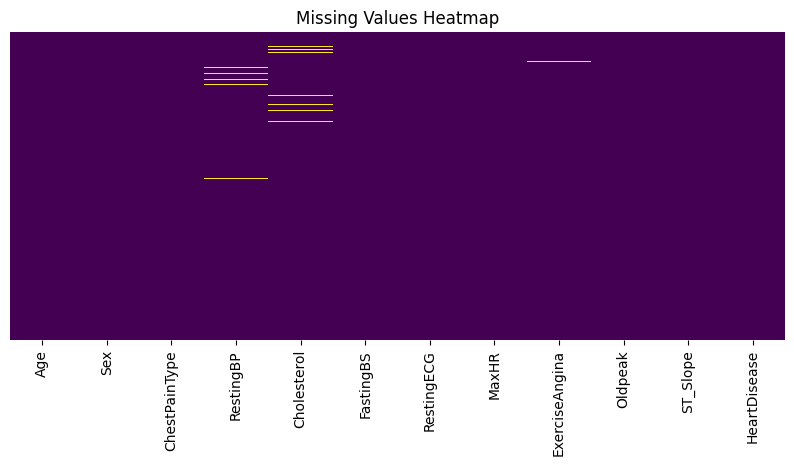

In [11]:
missing_counts = df.isnull().sum()
print("Missing values per column:\n", missing_counts)
import seaborn as sns
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [15]:
for col in ['RestingBP', 'Cholesterol']:
    if col in df.columns:
        mean_val = df[col].mean()
        df[col].fillna(mean_val, inplace=True)
        print(f"Filled missing values in {col} with mean: {mean_val:.2f}")
print(df[['RestingBP','Cholesterol']].isnull().sum())



Filled missing values in RestingBP with mean: 132.34
Filled missing values in Cholesterol with mean: 197.53
RestingBP      11
Cholesterol    22
dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_6524\1061871971.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(mean_val, inplace=True)


In [20]:
# Save the imputed dataset to a new file so the original remains unchanged
new_csv_path = r'C:\Users\HP\Desktop\internship\heart_imputed.csv'
df.to_csv(new_csv_path, index=False)
print(f"New dataset created: {new_csv_path}")

# Quick check of the new dataset
print("\nHead of the new dataset:")
print(df.head())

New dataset created: C:\Users\HP\Desktop\internship\heart_imputed.csv

Head of the new dataset:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA      140.0        289.0          0     Normal  172.0   
1   49   F           NAP      160.0        180.0          0     Normal  156.0   
2   37   M           ATA      130.0        283.0          0         ST   98.0   
3   48   F           ASY      138.0          NaN          0     Normal  108.0   
4   54   M           NAP      150.0        195.0          0     Normal  122.0   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


In [ ]:
# Load the newly created dataset and check missingness
new_df = pd.read_csv(new_csv_path)
print("Missing values in the new dataset (by column):")
print(new_df.isnull().sum())

# Visualize missingness in the new dataset
plt.figure(figsize=(10, 4))
sns.heatmap(new_df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap (New Dataset)')
plt.show()